In [1]:
import os
import json
from dataclasses import asdict
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from gap.classifiers import ScalableResNetLite
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer

from gap.purification.train_scriptv2 import GaussianDiffusion, HyperConfig, UNetLite

In [2]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models"

clf_metadata_path = os.path.join(RUN_DIR, "cifar10_metadata.json")
clf_weights_path = os.path.join(RUN_DIR, "cifar10_classifier.pth")

dm_metadata_path = os.path.join(RUN_DIR, "cifar10_diffusion/best_model.pt")

with open(clf_metadata_path, "r") as f:
    clf_best_model = json.load(f)

clf_best_config = clf_best_model["model_config"]
print(f"Loaded classifier config: {clf_best_config}")

Using device: mps
Loaded classifier config: {'lr': 0.0001838809343739058, 'channels': 96, 'depth': 4, 'optimizer': 'adam', 'weight_decay': 0.0005}


In [3]:
# Instantiate the model using the weights and metadata loaded
clf_trained_model = ScalableResNetLite(
    num_classes=10, channels=clf_best_config["channels"], depth=clf_best_config["depth"]
).to(device)

clf_trained_model.load_state_dict(
    torch.load(clf_weights_path, map_location=device, weights_only=True)
)
clf_trained_model.eval()
print("Classification model loaded successfully!")

Classification model loaded successfully!


In [4]:
def load_diffusion_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    hcfg_dict = checkpoint["hcfg"]
    hcfg = HyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparameters: {hcfg}")
    
    unet = UNetLite(
        in_channels=in_channels,
        base_channels=hcfg.base_channels,
        channel_mults=hcfg.channel_mults,
        num_res_blocks=hcfg.num_res_blocks,
        dropout=hcfg.dropout
    ).to(device)
    
    unet.load_state_dict(checkpoint["model"])
    unet.eval()
    
    diffusion = GaussianDiffusion(unet, num_timesteps=hcfg.num_timesteps).to(device)
    diffusion.eval()
    
    return diffusion, hcfg

def load_dae_model(checkpoint_path, in_channels=3, device="cpu"):
    return

In [ ]:
dm, dm_config = load_diffusion_model(RUN_DIR + "/cifar10_diffusion/best_model.pt")

In [4]:
# this is for normalizing the data loaded from cifar10. The data is testdata (test_batch I believe)
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

# There are 10000 test samples to choose from
test_subset = Subset(test_data, range(10000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Data loaded successfully! Ready for adversarial generation.


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Next steps: **Prepare the data for purification**
- Perform inference on the test data loaded with the loaded classification model.
- Identify all of the samples that were classified correctly and take that subset of samples.
- Generate adversarial data examples for all of those correctly classified samples from the test data. Use both PGD and FGSM.

In [5]:
attacker = AdversarialAttacker(clf_trained_model, device)

clean_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...


In [ ]:
fgsm_loader = attacker.generate_adversarial_dataset(
    clean_loader, attack_type="fgsm", epsilon=8 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    clean_loader, attack_type="pgd", epsilon=8 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [ ]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [8]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

In [9]:
len(pgd_dataset)

3523

In [ ]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_predictions_and_probs(model, dataloader, device):
    """Iterates through the dataloader to get true labels, predictions, and softmax probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def print_metrics(dataset_name, y_true, y_pred, y_prob):
    """Calculates and prints comprehensive metrics."""
    acc = accuracy_score(y_true, y_pred)
    # Using macro average to treat all classes equally
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    # ROC-AUC for multiclass requires the 'ovr' (One-vs-Rest) strategy
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    
    print(f"--- {dataset_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

print("Evaluating Clean Data...")
clean_y, clean_preds, clean_probs = get_predictions_and_probs(clf_trained_model, clean_loader, device)

print("Evaluating FGSM Data...")
fgsm_y, fgsm_preds, fgsm_probs = get_predictions_and_probs(clf_trained_model, fgsm_loader, device)

print("Evaluating PGD Data...")
pgd_y, pgd_preds, pgd_probs = get_predictions_and_probs(clf_trained_model, pgd_loader, device)

print_metrics("Clean Subset", clean_y, clean_preds, clean_probs)
print_metrics("FGSM Adversarial", fgsm_y, fgsm_preds, fgsm_probs)
print_metrics("PGD Adversarial", pgd_y, pgd_preds, pgd_probs)

Evaluating Clean Data...
Evaluating FGSM Data...
Evaluating PGD Data...
--- Clean Subset Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   0.9992

--- FGSM Adversarial Performance ---
Accuracy:  0.0823
Precision: 0.0389
Recall:    0.0397
F1-Score:  0.0373
ROC-AUC:   0.4679

--- PGD Adversarial Performance ---
Accuracy:  0.0315
Precision: 0.0126
Recall:    0.0138
F1-Score:  0.0129
ROC-AUC:   0.3998



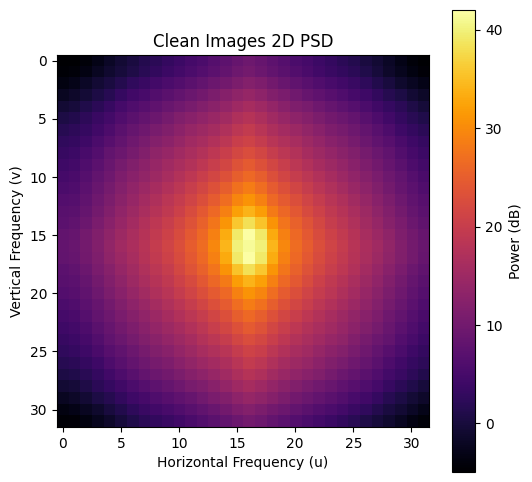

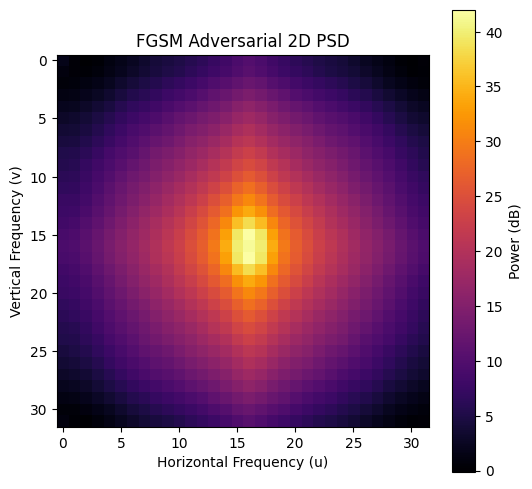

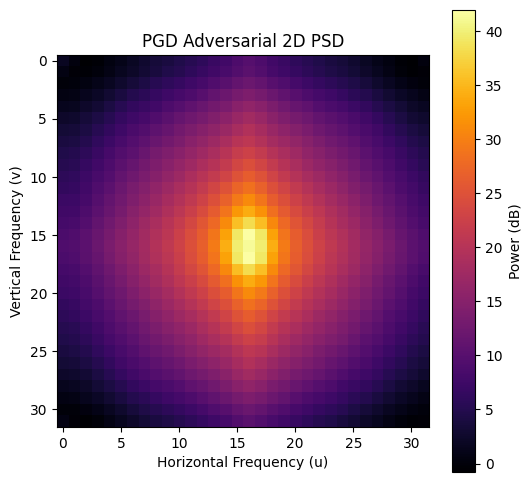

In [12]:
# Extract the underlying image tensors for plotting
clean_images, _ = clean_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(32, 32), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(clean_images, title="Clean Images 2D PSD")
analyzer.plot_2d(fgsm_images, title="FGSM Adversarial 2D PSD")
analyzer.plot_2d(pgd_images, title="PGD Adversarial 2D PSD")

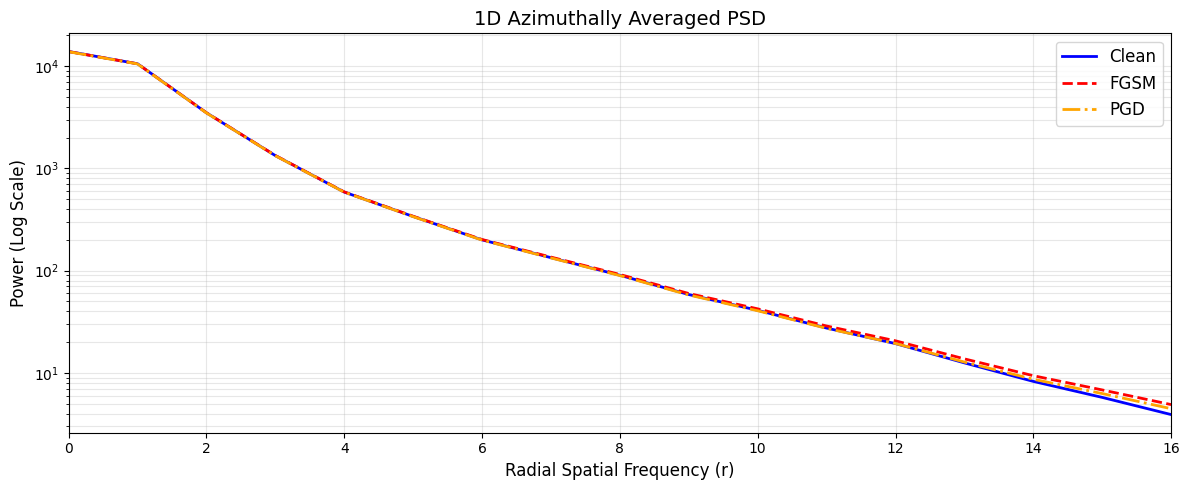

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:186: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=100)


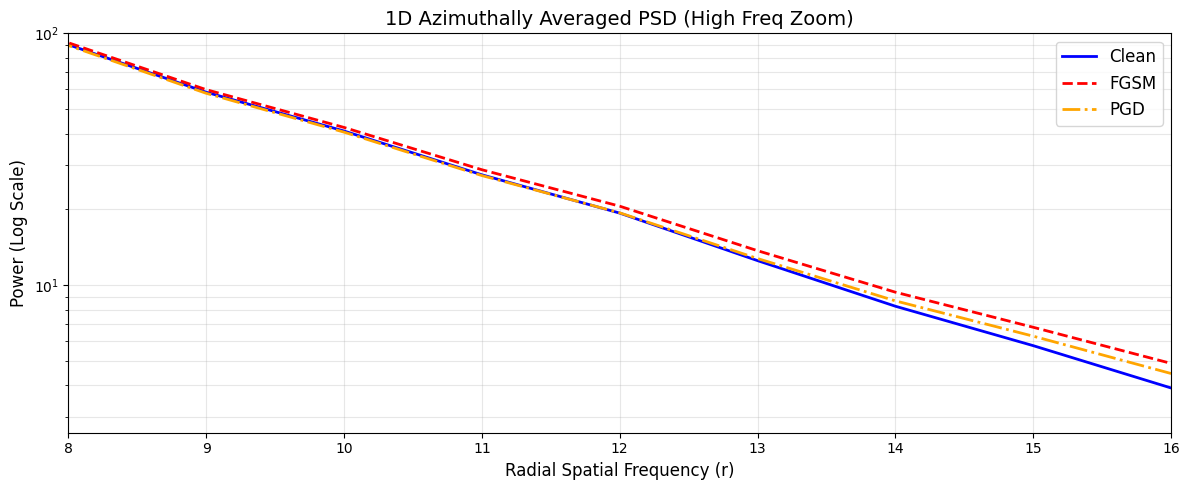

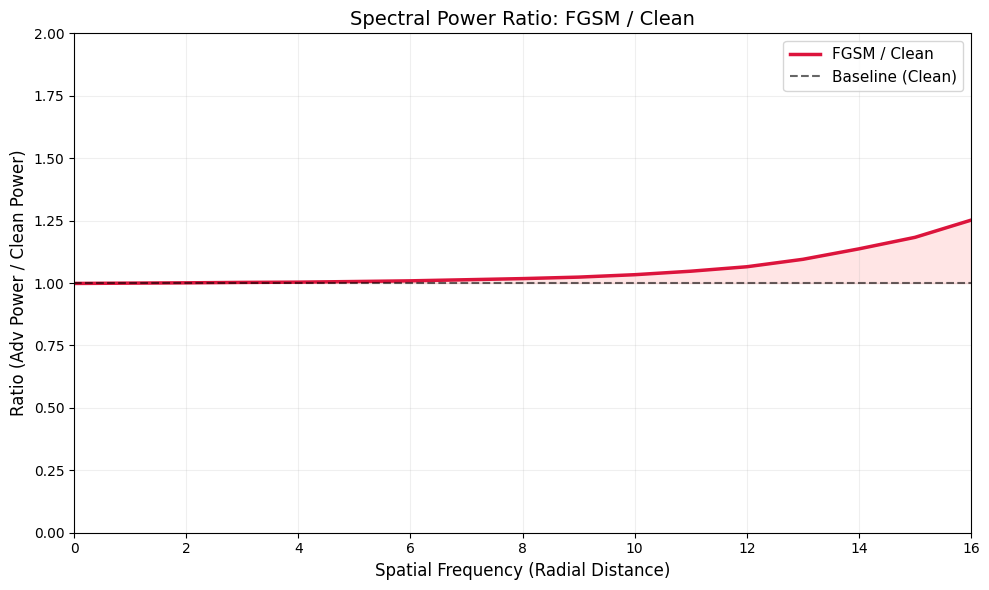

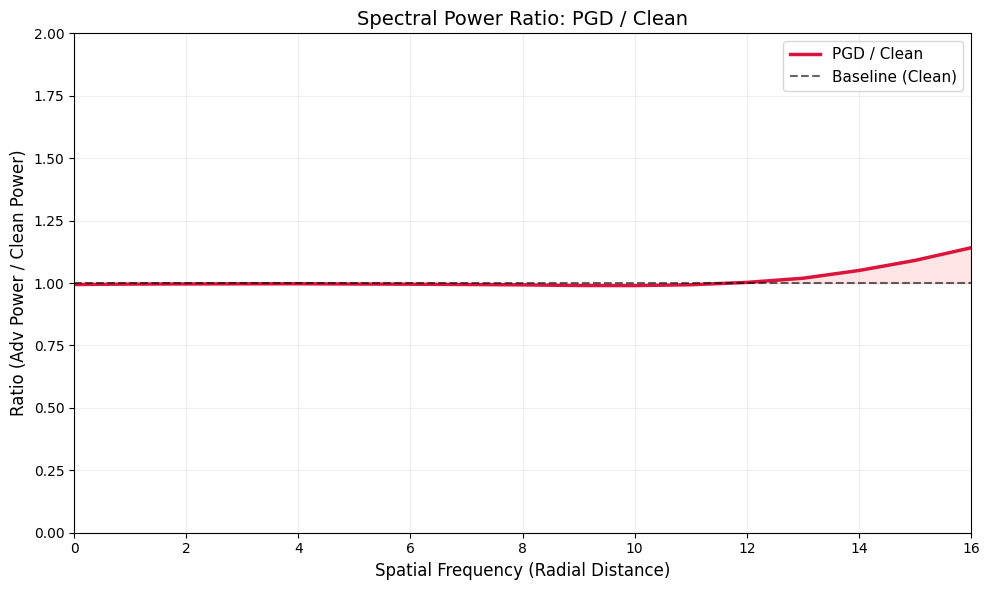

In [13]:
# Compare their 1D profiles on the same plot
analyzer.plot_1d({"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images})

# Compare their 1D profiles on the same plot
analyzer.plot_1d(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}, zoom_high_freq=True
)


analyzer.plot_1d_ratio(clean_images, fgsm_images, label="FGSM / Clean")
analyzer.plot_1d_ratio(clean_images, pgd_images, label="PGD / Clean")

Dataset    | Low-Freq Power (dB)  | High-Freq Power (dB)
-------------------------------------------------------
Clean      | 30.7068              | 12.6943             
FGSM       | 30.7245              | 13.0779             
PGD        | 30.6881              | 12.8173             


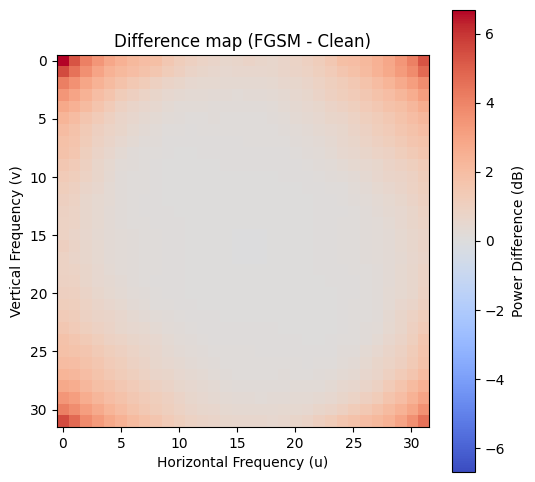

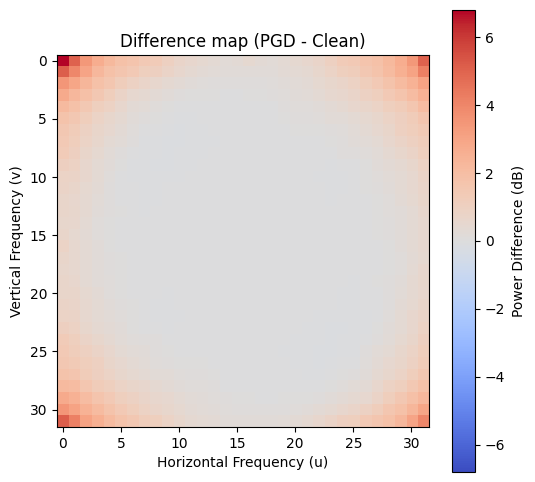

In [14]:
analyzer.print_spectral_stats(
    {"Clean": clean_images, "FGSM": fgsm_images, "PGD": pgd_images}
)

analyzer.plot_2d_difference(
    images_base=clean_images,
    images_adv=fgsm_images,
    title="Difference map (FGSM - Clean)",
)
analyzer.plot_2d_difference(
    images_base=clean_images,
    images_adv=pgd_images,
    title="Difference map (PGD - Clean)",
)